Diesmal das Random Forest Modell ohne Imputer, also alle Zeilen mit NA-Werten sind raus.

Schritt 1: Entferne alle Zeilen mit fehlenden Werten (Wolken-Tage)...
-> Von 574 Beobachtungen bleiben nach dem Löschen 145 perfekte Sonnentage übrig.

Führe Baseline-Kalibrierung der Hardware durch...
-> Systematischer Offset: 4.88 µg/m³
-> Low-Cost-Sensoren wurden auf das Kopfklinik-Niveau angehoben!
Schritt 2: Starte LLO-Kreuzvalidierung (Complete-Case Analysis)...
Fold 1 (Test auf Sensor 10645): R² =  0.12 | RMSE = 1.77 µg/m³ | Bias =  1.57 µg/m³
Fold 2 (Test auf Sensor 13975): R² =  0.47 | RMSE = 1.57 µg/m³ | Bias =  1.09 µg/m³
Fold 3 (Test auf Sensor 19623): R² =  0.56 | RMSE = 1.60 µg/m³ | Bias = -0.78 µg/m³
Fold 4 (Test auf Sensor 25049): R² =  0.24 | RMSE = 2.12 µg/m³ | Bias = -1.40 µg/m³

GESAMTERGEBNIS OHNE IMPUTATION (Nur lückenlose Tage):
Mittlerer R² Score:   0.35
Mittlerer RMSE:       1.77 µg/m³
Mittlerer Bias:       0.12 µg/m³
--------------------------------------------------
FEATURE WICHTIGKEIT:
        icon_temp_2m:  35.2 %
             S5P_NO2:  21.4 %
icon_relative

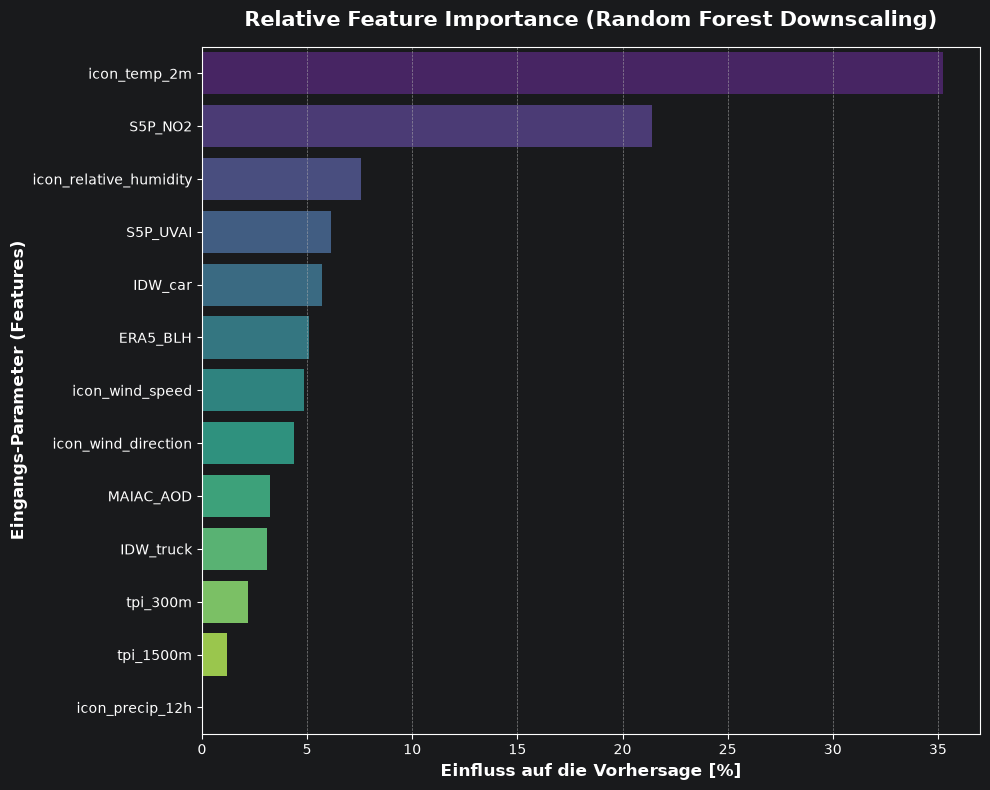

-> Feature Importance Plot erfolgreich gespeichert unter:
   C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Diagrams\Feature_Importance_RF_Model.png


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. Daten laden & bereinigen
# =========================================================
file_path = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"
df = pd.read_csv(file_path, sep=";", decimal=",")

df['station_id'] = df['station_id'].astype(str).str.strip()

# Kaputte / verzerrende Sensoren entfernen
bad_sensors = ['5456', '15449', '46505']
df = df[~df['station_id'].isin(bad_sensors)].copy()

features = [
    #'prox_kumulativ_car', 'prox_kumulativ_truck',
    'IDW_car', 'IDW_truck',
    'icon_temp_2m', 'icon_wind_speed', 'icon_wind_direction',
    'icon_precip_12h', 'icon_relative_humidity',
    'MAIAC_AOD', 'S5P_NO2', 'S5P_UVAI', 'ERA5_BLH',
    'tpi_300m', 'tpi_1500m'
]

# --- DIE ENTSCHEIDENDE ÄNDERUNG: KOMPLETTER AUSSCHLUSS VON NA-WERTEN ---
print("Schritt 1: Entferne alle Zeilen mit fehlenden Werten (Wolken-Tage)...")
vorher_len = len(df)
df = df.dropna(subset=['PM25_Target'] + features)
nachher_len = len(df)
print(f"-> Von {vorher_len} Beobachtungen bleiben nach dem Löschen {nachher_len} perfekte Sonnentage übrig.\n")

# Qualitäts-Filter: Mindestens 10 Tage (Herabgesetzt, da wir massiv Daten verloren haben!)
sensor_counts = df['station_id'].value_counts()
valid_sensors = sensor_counts[sensor_counts >= 10].index
df = df[df['station_id'].isin(valid_sensors)].copy()

## HIER WERDEN DIE LOW-COST SENSOREN DER KOPFKLINIK ANGEPASST
# =========================================================
# Hardware-Kalibrierung: Low-Cost an Kopfklinik anpassen
# =========================================================
print("Führe Baseline-Kalibrierung der Hardware durch...")

# 1. Berechne das mittlere Niveau der offiziellen Kopfklinik (Station "1")
mean_kopfklinik = df[df['station_id'] == "1"]['PM25_Target'].mean()

# 2. Berechne das mittlere Niveau aller Low-Cost-Sensoren
mean_lowcost = df[df['station_id'] != "1"]['PM25_Target'].mean()

# 3. Ermittle den systematischen Offset (Hardware-Unterschied)
offset = mean_kopfklinik - mean_lowcost
print(f"-> Systematischer Offset: {offset:.2f} µg/m³")

# 4. Hebe alle Low-Cost-Sensoren um diesen Offset an
df.loc[df['station_id'] != "1", 'PM25_Target'] += offset

print("-> Low-Cost-Sensoren wurden auf das Kopfklinik-Niveau angehoben!")
# =========================================================


# =========================================================
# 2. Leave-Location-Out (LLO) Validierung
# =========================================================
print("Schritt 2: Starte LLO-Kreuzvalidierung (Complete-Case Analysis)...")

ANCHOR_ID = "1"
test_stations = [s for s in df['station_id'].unique() if s != ANCHOR_ID]

fold_results = []
rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=4, random_state=42, n_jobs=-1)

feature_importances_list = []

for fold, test_sensor in enumerate(test_stations, 1):
    test_mask = df['station_id'] == test_sensor
    df_test = df[test_mask]
    df_train = df[~test_mask]

    # Überspringe Sensoren, die nach dem DropNA gar keine Testdaten mehr haben
    if len(df_test) == 0:
        continue

    X_train = df_train[features]
    y_train = df_train['PM25_Target']
    X_test = df_test[features]
    y_test = df_test['PM25_Target']

    sample_weights = np.where(df_train['station_id'] == ANCHOR_ID, 1.0, 1.0)

    rf.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    bias = np.mean(y_pred - y_test)

    fold_results.append({'Sensor': test_sensor, 'R2': r2, 'RMSE': rmse, 'Bias': bias})
    feature_importances_list.append(rf.feature_importances_)

    print(f"Fold {fold} (Test auf Sensor {test_sensor}): R² = {r2:5.2f} | RMSE = {rmse:4.2f} µg/m³ | Bias = {bias:5.2f} µg/m³")

# =========================================================
# 3. Endauswertung & Feature Importance
# =========================================================
print("\n" + "="*50)
print("GESAMTERGEBNIS OHNE IMPUTATION (Nur lückenlose Tage):")
print("="*50)
results_df = pd.DataFrame(fold_results)
print(f"Mittlerer R² Score:   {results_df['R2'].mean():.2f}")
print(f"Mittlerer RMSE:       {results_df['RMSE'].mean():.2f} µg/m³")
print(f"Mittlerer Bias:       {results_df['Bias'].mean():.2f} µg/m³")
print("-" * 50)

if feature_importances_list:
    mean_importances = np.mean(feature_importances_list, axis=0)
    importance_df = pd.DataFrame({'Feature': features, 'Wichtigkeit (%)': mean_importances * 100})
    importance_df = importance_df.sort_values(by='Wichtigkeit (%)', ascending=False)
    print("FEATURE WICHTIGKEIT:")
    for idx, row in importance_df.iterrows():
        print(f"{row['Feature']:>20}: {row['Wichtigkeit (%)']:5.1f} %")
else:
    print("Nicht genügend Daten für Feature Importance.")
print("="*50)

# =========================================================
# 4. Feature Importance Visualisierung (PNG Export)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import os

if feature_importances_list:
    # Ausgabepfad definieren
    output_dir = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Diagrams"
    os.makedirs(output_dir, exist_ok=True)
    plot_path = os.path.join(output_dir, "Feature_Importance_RF_Model.png")

    # Plot initialisieren
    plt.figure(figsize=(10, 8))

    # Balkendiagramm erstellen (nutzt dein bestehendes importance_df)
    sns.barplot(
        x='Wichtigkeit (%)',
        y='Feature',
        data=importance_df,
        palette='viridis' # Schöne, wissenschaftliche Farbpalette
    )

    # Layout & Styling
    plt.title('Relative Feature Importance (Random Forest Downscaling)', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Einfluss auf die Vorhersage [%]', fontsize=12, fontweight='bold')
    plt.ylabel('Eingangs-Parameter (Features)', fontsize=12, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Ränder anpassen, speichern und anzeigen
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"-> Feature Importance Plot erfolgreich gespeichert unter:\n   {plot_path}")

In [3]:
import pandas as pd
import numpy as np

# Pfade zu den beiden CSV-Dateien
file_old = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"
file_new = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\allValues_Features_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"

print("="*70)
print("VERGLEICHSANALYSE DER ZWEI FEATURE-DATENSÄTZE")
print("="*70)

# Daten laden
df_old = pd.read_csv(file_old, sep=";", decimal=",")
df_new = pd.read_csv(file_new, sep=";", decimal=",")

# Strings säubern
df_old['station_id'] = df_old['station_id'].astype(str).str.strip()
df_new['station_id'] = df_new['station_id'].astype(str).str.strip()

# 1. Gesamtstruktur
print(f"\n1. GESAMTSTRUKTUR:")
print(f"   Alte Datei: {len(df_old):>5} Zeilen | {len(df_old.columns)} Spalten")
print(f"   Neue Datei: {len(df_new):>5} Zeilen | {len(df_new.columns)} Spalten")
print(f"   Differenz:  {len(df_new) - len(df_old):>+5} Zeilen")

# 2. Beobachtungen pro Station
print(f"\n2. BEOBACHTUNGEN PRO STATION (station_id):")
s_old = df_old['station_id'].value_counts()
s_new = df_new['station_id'].value_counts()

all_stations = sorted(list(set(s_old.index).union(set(s_new.index))))
print(f"   {'Station ID':<15} | {'Alte Datei':<12} | {'Neue Datei':<12} | {'Differenz':<10}")
print("   " + "-"*58)
for st in all_stations:
    c_old = s_old.get(st, 0)
    c_new = s_new.get(st, 0)
    diff = c_new - c_old
    print(f"   {st:<15} | {c_old:<12} | {c_new:<12} | {diff:>+10d}")

# 3. PM2.5-Zielwert Statistiken pro Station
print(f"\n3. PM2.5 TARGET-STATISTIKEN PRO STATION:")
for st in all_stations:
    sub_old = pd.to_numeric(df_old[df_old['station_id'] == st]['PM25_Target'].astype(str).str.replace(',', '.'), errors='coerce').dropna()
    sub_new = pd.to_numeric(df_new[df_new['station_id'] == st]['PM25_Target'].astype(str).str.replace(',', '.'), errors='coerce').dropna()

    m_old, std_old = (sub_old.mean(), sub_old.std()) if len(sub_old)>0 else (np.nan, np.nan)
    m_new, std_new = (sub_new.mean(), sub_new.std()) if len(sub_new)>0 else (np.nan, np.nan)

    print(f"   Station {st}:")
    print(f"     Alt -> Mean: {m_old:5.2f} µg/m³ | Std: {std_old:5.2f} | N = {len(sub_old)}")
    print(f"     Neu -> Mean: {m_new:5.2f} µg/m³ | Std: {std_new:5.2f} | N = {len(sub_new)}")

# 4. Fehlende Werte (NaN) im Vergleich
print(f"\n4. FEHLENDE WERTE (NaN) PRO FEATURE:")
features = [c for c in df_old.columns if c not in ['date', 'station_id']]
print(f"   {'Feature':<22} | {'Alt NaNs':<10} | {'Neu NaNs':<10}")
print("   " + "-"*48)
for f in features:
    if f in df_old.columns and f in df_new.columns:
        nan_old = df_old[f].isna().sum()
        nan_new = df_new[f].isna().sum()
        print(f"   {f:<22} | {nan_old:<10} | {nan_new:<10}")

# 5. Datumsbereich
print(f"\n5. DATUMSSPANNE:")
print(f"   Alte Datei: {df_old['date'].min()} bis {df_old['date'].max()} ({df_old['date'].nunique()} Tage)")
print(f"   Neue Datei: {df_new['date'].min()} bis {df_new['date'].max()} ({df_new['date'].nunique()} Tage)")

print("="*70)

VERGLEICHSANALYSE DER ZWEI FEATURE-DATENSÄTZE

1. GESAMTSTRUKTUR:
   Alte Datei:   776 Zeilen | 22 Spalten
   Neue Datei:   850 Zeilen | 22 Spalten
   Differenz:    +74 Zeilen

2. BEOBACHTUNGEN PRO STATION (station_id):
   Station ID      | Alte Datei   | Neue Datei   | Differenz 
   ----------------------------------------------------------
   1               | 48           | 122          |        +74
   10645           | 88           | 88           |         +0
   13975           | 123          | 123          |         +0
   15449           | 123          | 123          |         +0
   19623           | 116          | 116          |         +0
   25049           | 123          | 123          |         +0
   46505           | 31           | 31           |         +0
   5456            | 122          | 122          |         +0
   9094            | 2            | 2            |         +0

3. PM2.5 TARGET-STATISTIKEN PRO STATION:
   Station 1:
     Alt -> Mean:  6.75 µg/m³ | Std:  2.76